# Airline Passenger Growth & Seasonality Time-Series Analysis

metadata here

### 1. Set-up and Data Inspection

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid') # set visual style

df_flights = sns.load_dataset('flights') # load built-in flights dataset

print("Dataset shape: ", df_flights.shape)
print("\nData Types & Info: ")
print(df_flights.info())

df_flights.head(12) # display a full 1-year cycle (month is in ascending by default in this dataset)

Dataset shape:  (144, 3)

Data Types & Info: 
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB
None


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
5,1949,Jun,135
6,1949,Jul,148
7,1949,Aug,148
8,1949,Sep,136
9,1949,Oct,119


### 2. Feature Engineering (Creating Datetime & Growth Metrics)
To analyze temporal trends effectively, we engineer two columns:
1. `year_month`/`date`: a combined datetime column (YYYY-MM-01) for continuous time-series plotting
2. `yoy_growth`: Year-over-Year percentage change compared to the exact same month in the previous year.

In [2]:
df_clean = df_flights.copy() # creating copy so that original won't be affected

# create a true datetime column for time-series axes
# 1. .astype(str): converts numerical years/months into text (strings); 2024 becomes '2024'
# 2. pd.to_datetime(...): converts combined text string into an actual pandas datetime64 data type
# using datetime64 data type gives pandas calendar intelligence
df_clean['date'] = pd.to_datetime(
    df_clean['year'].astype(str) + '-' + df_clean['month'].astype(str) + '-01'
) 

# sort chronologically as ['date'] is now of datatype datetime64
# 1. .sort_values('date'): reorders all rows first in chronological order based on 'date' column (oldest dates to newest)
# 2.a. .reset_index(): generates a brand new index (this is a new column; 0, 1, 2) because we did sorting. without this, index won't be chronological. 
# 2.b. drop=True: tells pandas to discard the old index instead of keeping it as a regular column (since reset_index() does the reordering of index)
df_clean = df_clean.sort_values('date').reset_index(drop=True) 

# calculate YoY growth per month (% change compared to 12 months prior)
df_clean['yoy_growth_pct'] = df_clean['passengers'].pct_change(12) * 100 # pct.change(12) is a built-in method in pandas; calculates fractional change

df_clean.head(15)

,year,month,passengers,date,yoy_growth_pct
0,1949,Jan,112,1949-01-01,NaN
1,1949,Feb,118,1949-02-01,NaN
2,1949,Mar,132,1949-03-01,NaN
3,1949,Apr,129,1949-04-01,NaN
4,1949,May,121,1949-05-01,NaN
5,1949,Jun,135,1949-06-01,NaN
6,1949,Jul,148,1949-07-01,NaN
7,1949,Aug,148,1949-08-01,NaN
8,1949,Sep,136,1949-09-01,NaN
9,1949,Oct,119,1949-10-01,NaN


### 3. Overall Long-Term Trend Plot 
Using `sns.lineplot`. We visualize the macro trajectory of air travel from 1949 to 1960.

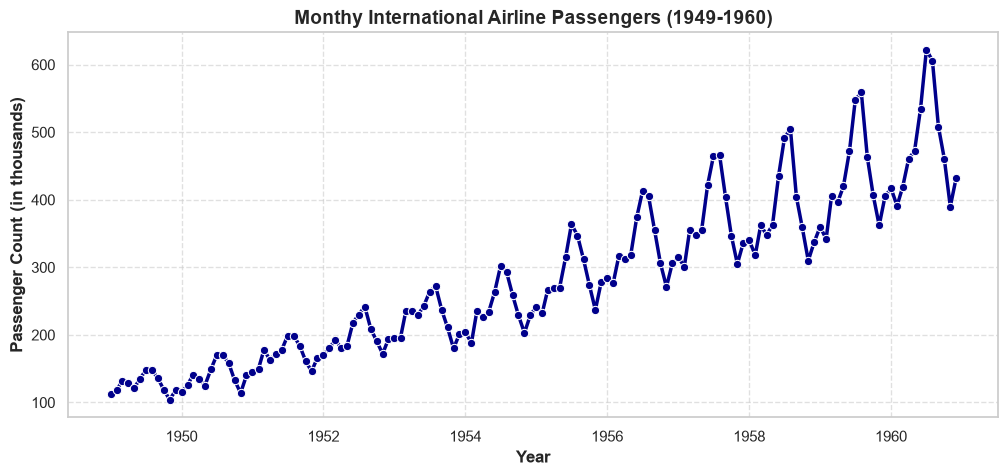

In [3]:
plt.figure(figsize=(12, 5)) # set-up canvas

# continuous time-series line plot
sns.lineplot(
    data=df_clean,
    x='date',
    y='passengers',
    color='darkblue',
    linewidth=2.5,
    marker='o'
)

plt.title('Monthy International Airline Passengers (1949-1960)', fontweight='bold', fontsize=14)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Passenger Count (in thousands)', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6) # enable grid lines with linestyle of '--' and alpha = 0.6
plt.show()

### 4. Seasonality Analysis (Overlaying Yearly Curves)

Does travel surge during specific months every year? We overlay annual curves using `hue=year` to isolate seasonal rhythms.

NameError: name 'bold' is not defined

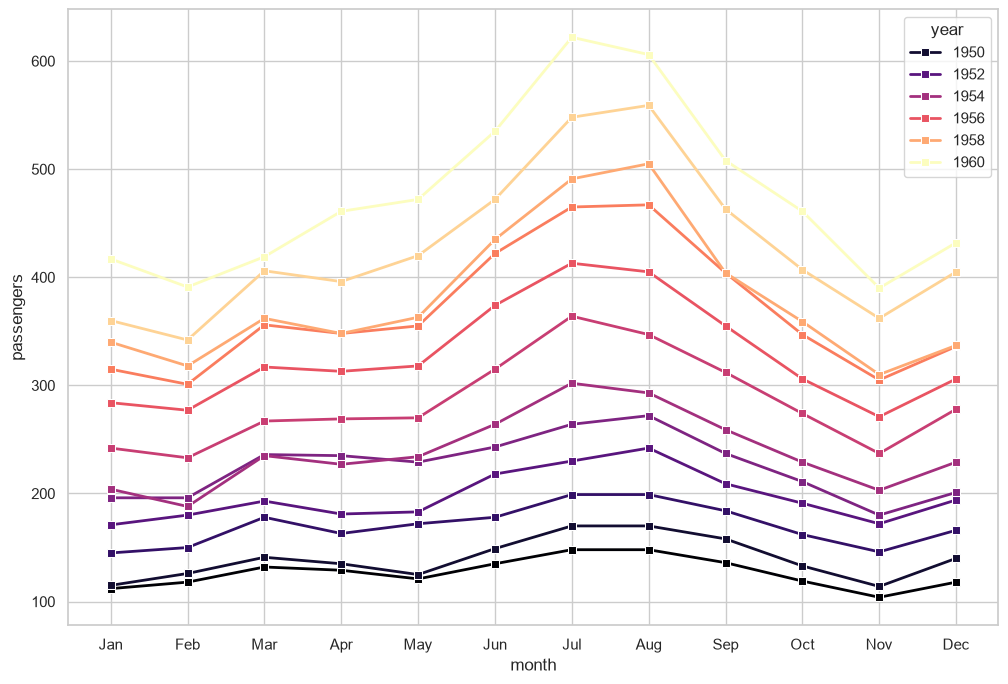

In [4]:
plt.figure(figsize=(12, 8)) # set canvas

# monthly trends color-coded by year
sns.lineplot(
    data=df_clean,
    x='month',
    y='passengers',
    hue='year',
    palette='magma',
    linewidth=2,
    marker='s'
)

plt.title('Seasonal Travel Patterns Segmented by Year (1949-1960', fontweight=bold)
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Passengers (thousands)', fontweight='bold')
plt.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()